# Sampling in R

**Definition.** For a fixed population and fixed sample size $k\in \mathbb{N}$, a collection of values of the mean over $n$ samples of size $k$ forms what we call a <span style="color:maroon; font-weight:bold">sampling distribution</span>.

The sampling distribution is one key foundation of statistics. In this notebook, we will learn to use the sampling functions in R to sample various distributions.

<span style="color:maroon; font-weight:bold">To create a (partial) sampling distribution:</span>

- Draw repeated random samples of the same size.
- Take the average of each sample.
- The averages are the sampling distribution, or a subset thereof.

We will cover more of the theory in the next notebook including the <span style="color:maroon; font-weight:bold">Central Limit Theorem</span> and the <span style="color:maroon; font-weight:bold">Law of Large Numbers</span>.

## Getting Started

To accomplish sampling in R, we will use four functions from the **mosaic** package:

1. **rflip()** -- Simulates a coin flip or binomial distribution.
2. **rspin()** -- Simulates a spinner which allows for multiple categories each with a unique probability of occuring.
3. **sample()** -- Draw a random sample of rows from a given data frame.
4. **do()** -- Quickly loops through a sampling function to create multiple random samples and store them in a data frame.

Run the cell below to load the **mosaic** package so the above functions can be used.

In [2]:
library('mosaic')

### Data

We will also need data sets to draw samples from. **We will load 2 data frames:**

- **united** $\hspace{3mm}$ Delay in minutes of 14,000 flights on United Airlines.
- **pers** $\hspace{7mm}$ Personality variables data frame.

**Run the cell below to import the data.**

In [2]:
united <- read.csv('http://faculty.ung.edu/rsinn/data/united.csv')
pers <- read.csv('http://faculty.ung.edu/rsinn/data/personality.csv')

## rflip()

This function, as the name seems to indicate, produces a coin flipping simulation where we can control the size of the sample taken and the probability of success (e.g. "heads"). The **rflip()** function has several helpful parameters:

- <span style="color:blue; font-weight:bold">prob</span> $\hspace{3mm}$ The probability of success.
- <span style="color:blue; font-weight:bold">summarize</span> $\hspace{3mm}$  Summarize results efficiently.

Run the cells below to see examples of how the mosaic function <font color="blue"><center><b>rflip()</b></center></font> creates repeated coin flips with varying chances of success.

1. Base function with $\textbf{prob =}$ option to adjust chance of success.

In [3]:
## Base function with prob option to adjust chance of success.

rflip(20, prob = 0.25)


Flipping 20 coins [ Prob(Heads) = 0.25 ] ...

T T T H T T T H T T T T T H H T T T T T

Number of Heads: 4 [Proportion Heads: 0.2]


2. Example using $\textbf{summarize =  TRUE}$ to efficiently descibe results.

In [4]:
## summarize option
## Simplifies the output. Details remain, but layout is more efficient.

rflip(20, summarize = TRUE)

n,heads,tails,prob
<dbl>,<int>,<dbl>,<dbl>
20,9,11,0.5


## Example using <span style = 'color:maroon;font-weight:bold'>rflip()</span> Function

The task:
1. Simulate 10 coin flips.
2. Run the simulation 100 times.
3. From results dataframe, create histogram and descriptive statistics.

We will progress in order to write and understand the code needed.

### 1. Simulate 10 coin flips.

In [5]:
rflip(10, summarize = TRUE)

n,heads,tails,prob
<dbl>,<int>,<dbl>,<dbl>
10,6,4,0.5


### 2. Run Simulation 100 Times

We will collect and store the results in the variable $\textbf{simulation\_results}$.

In [6]:
simulation_results <- do(100) * rflip(25, prob = 0.35)

Let's inspect the results of using the <font color="blue"><center><b>do()</b></center></font> function to run the simulation repeatedly.

In [7]:
head(simulation_results, 5)

,n,heads,tails,prop
,<dbl>,<dbl>,<dbl>,<dbl>
1,25,7,18,0.28
2,25,8,17,0.32
3,25,7,18,0.28
4,25,11,14,0.44
5,25,5,20,0.20


In [8]:
num_success <- simulation_results[ , 'heads']
num_success

[1]  7  8  7 11  5  7 12 10 11  5 10  6  6 10  9 10 11 12  8  9  8  7  6  8  4
 [26]  9 11 10 10 11  7  5  3  7  7 10 14 10  5 12 12  7 12  6  7  8  6 10  7  9
 [51] 10 10  6 12  9 10 13 11  9 10  4  9  7 11  5 10  5 14  5  9 11  7 11  6 11
 [76] 11 11  9 11 12 12  7  7 11  8  9  8 11  5 10  5 13  6  9 12  8 12  7 10  9

### 3. Histogram and Descriptive Statistics.

In statistics, we often use the middle 90\% of a normal (e.g. bell-shaped) distribution to estimate the mean of that distribution. To do so, let's calculate:

- 5th percentile
- 95th percentile

With these values, we have an interval estimate of the mean number successes from this coin flipping distribution. We can show the interval by superimposiing lines on a histogram of the distribution. To make the code very flexible if we wish to reuse it, we introduce a few variables:

1. **num_success** $\hspace{3mm}$ Results vector that stores the number of successes in each sample.

2. **samp_size** $\hspace{8mm}$ Sample size

3. **probability** $\hspace{7mm}$ Probability of success
   
4. **lower** $\hspace{16mm}$ 5th percentile

5. **upper**$\hspace{16mm}$ 95th percentile

We will use the **paste()** function within the main title of the histogram which allows us to include the values of sample size and probability on the histogram itself.

The mean of the simulated distribution is
    8.8 
and the 90% interval is
   from 5  to  12

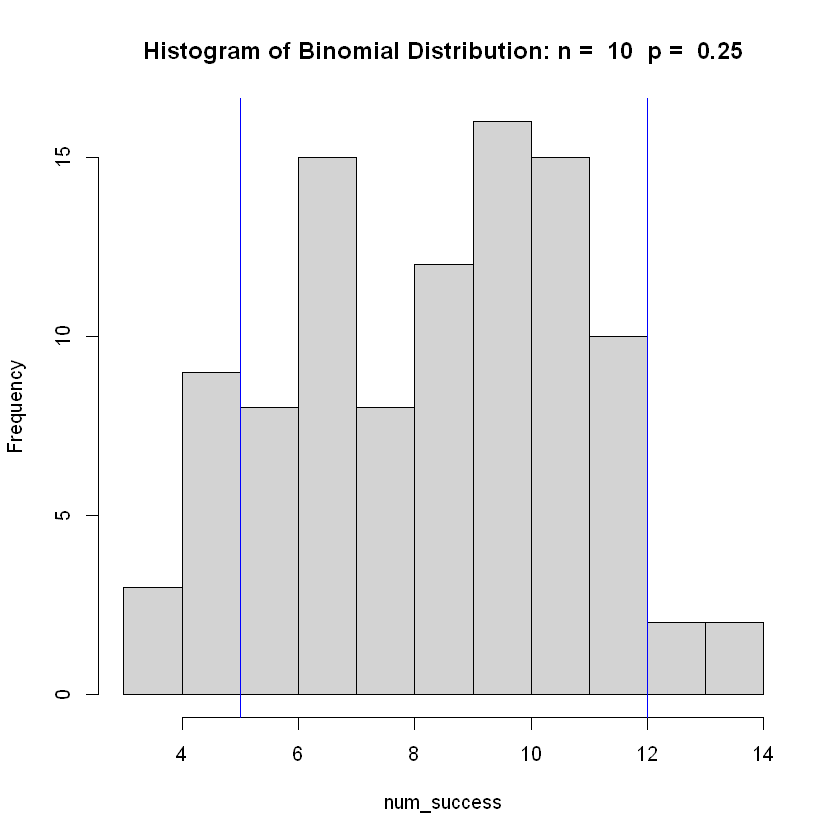

In [9]:
num_success <- simulation_results[ , 'heads']   # Results vector we will use to store results when available.
samp_size <- 10
probability <- 0.25
lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success),
    '\nand the 90% interval is\n   from', lower, ' to ',upper )
hist(num_success, breaks = 12, main = paste('Histogram of Binomial Distribution: n = ', samp_size,' p = ',probability))
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

### Putting it all together

The code below does everything at once.

The mean of the simulated distribution is
    2.26 
and the 90% interval is
   from  0  to  5

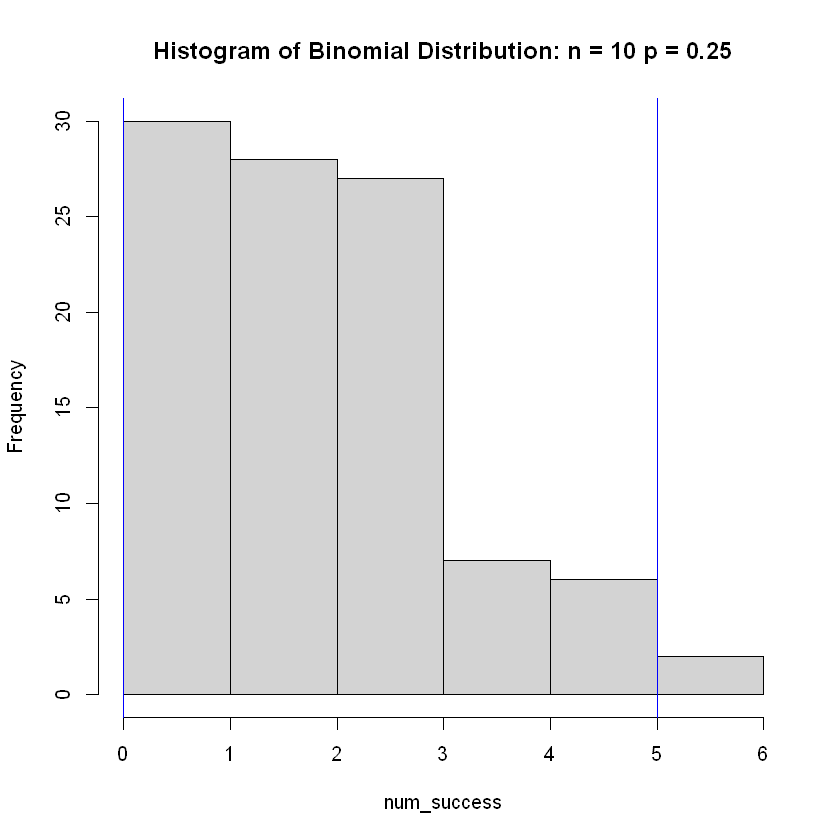

In [10]:
num_success <- c()
num_samps = 100
samp_size <- 10
probability <- 0.25

temp <- do(num_samps) * rflip(samp_size, prob = probability)
num_success <- temp[ , 'heads']

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success),
    '\nand the 90% interval is\n   from ', lower, ' to ', upper )
hist(num_success, breaks = 8, main = paste('Histogram of Binomial Distribution: n =', samp_size ,'p = 0.25'))
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

### Analysis of Results

First, note that the average of the sample averages is $2.64$. Since $n=10$ and the probability of success was $0.25$, our expectation is that about $2.5$ successes will occur in 10 trials. The value of $2.64$ is very close. We will be likely to gain accuracy as sample size increases which we can accomplish in two ways:
- Increase sample size of individual samples, or
- Increase total number of samples taken.

### Additional Tasks to Promote Understanding

1. Rerun the above code with increasing sample sizes, say $n=25$ or $n=50$.
2. Rerun the code with a larger number of samples, say $n=750$ or $n=1000$.
3. Notice how the increased sample size changes the histogram, confidence interval and estimate of the mean.

## Example Using the <span style = 'color:maroon;font-weight:bold'>sample()</span> Function

We will take 500 samples from the **pers** data set using different sample sizes:

- 5
- 10
- 20

We are limited by an oversampling concern, so a sample size of $n=20$ is as large as we can use.

Let's take a simple random sample of the **pers** dataframe. Notice that the **sample()** returns a dataframe that is a subset of the original. The rows of the dataframe are number, and R finds a simple random sample of those values. Those row numbers are then used to create the output.

In [11]:
sample(pers,5)

,Age,Yr,Sex,G21,Corps,Res,Greek,VarsAth,Honor,GPA,...,OCD,Play,Extro,Narc,HSAF,HSSE,HSAG,HSSD,PHS,orig.id
,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>
47,20,2,F,N,N,1,N,N,N,2.90,...,7,170,12,6,53,42,37,26,AF,47
13,20,2,M,N,N,1,N,N,Y,3.86,...,15,130,10,8,43,36,36,32,AG,13
48,20,2,M,N,N,1,N,N,N,3.49,...,6,134,7,6,36,31,33,35,SD,48
88,19,2,F,N,N,1,N,N,N,3.75,...,11,141,14,3,44,35,19,17,AF,88
113,22,2,F,Y,N,2,N,N,N,3.49,...,11,141,9,1,44,38,23,31,SD,113


We will need to extract the Naricssism values which proceeds as follows:

In [12]:
sample(pers, 20)[ , 'Narc']

[1] 1 8 2 8 3 2 1 4 6 9 8 5 6 8 0 1 6 2 4 9

The mean of the simulated distribution is
    4.3 
and the 90% interval is
   from  0.95  to  9.1

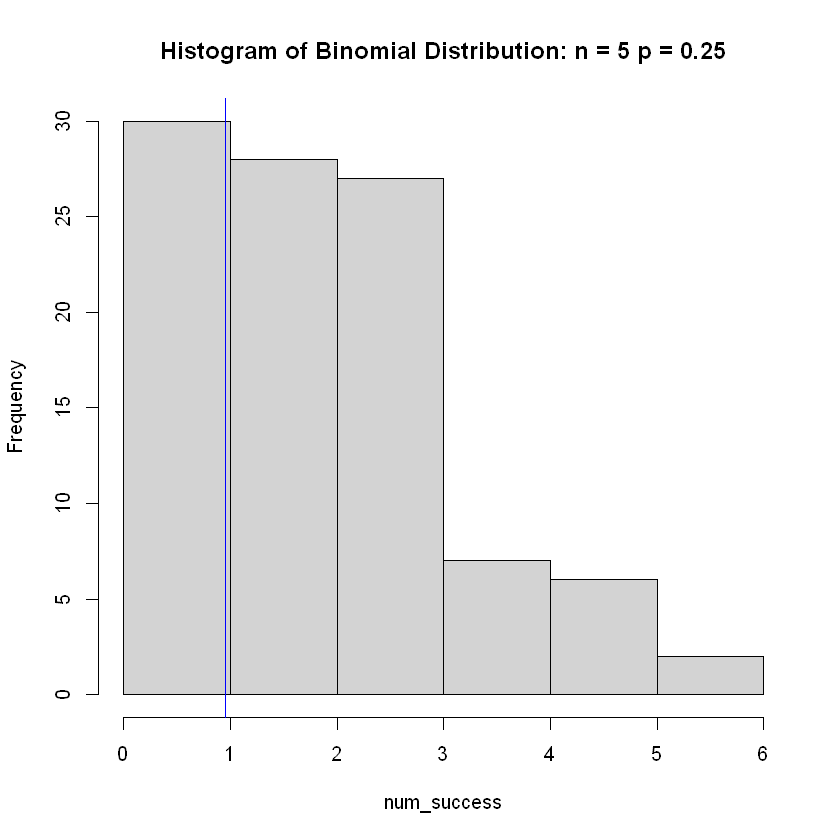

In [13]:
temp <- c()
num_samps = 500
samp_size <- 5

results <- sample(pers, 20)[ , 'Narc']
lower <- quantile(results, prob = 0.05)
upper <- quantile(results, prob = 0.95)
cat('The mean of the simulated distribution is\n   ',mean(results),
    '\nand the 90% interval is\n   from ', lower, ' to ', upper )
hist(num_success, breaks = 8, main = paste('Histogram of Binomial Distribution: n =', samp_size ,'p = 0.25'))
abline( v = lower, col="blue") 
abline(v = upper, col="blue")

### Additional Tasks to Promote Understanding

1. Create code to generate the means of 500 samples where $n=10$.
2. Rerun the above code with a increasingly larger samples, say $n=15$ and $n=20$.
3. Notice how the increased sample size changes the histogram, confidence interval and estimate of the mean.

## Example Using rspin() Function

Suppose that we have spinner with Red, Blue, Green and Yellow regions. The spinner lands in these regions with probabilities 20%, 30%, 40% and 10% respectively. The basic function, unlike **rflip()**, will not work by simply specifying sample size. The function needs details about the spinner regions and probabilities:

1. **probs** $\hspace{3mm}$ Vector with probabilities of successes for each sector (must sum to 1).

2. **labels** $\hspace{2mm}$ Names using text that identify the different sectors.

The command below will conduct 50 simulations for the spinner described for this example. I have inserted some hard returns into the command which R ignores but which make the logic of the command easier follow.

In [14]:
rspin( n = 50,
  labels = c("Red", "Blue", "Green", "Yellow"),
  probs = c(0.2, 0.3, 0.4, 0.1)
)

Red,Blue,Green,Yellow
<int>,<int>,<int>,<int>
11,16,20,3


### Example with rspin(): Estimating Percent of Yellow

The scientific idea here is to estimate with increasing confidence the percentage of times that the spinner lands in the Yellow region. We therefore need to extract the number of Yellow spins from the results dataframe. To simply our **rspin()** function call, lets create variable for the labels and probabilities.

In [15]:
p <- c(0.2, 0.3, 0.4, 0.1)
lab <- c("Red", "Blue", "Green", "Yellow")
results <-rspin( n = 50, labels = lab , probs = p )
results[ , 'Yellow']
percent_results <- results / 50

[1] 6

### Adding do() Function

We will add variables for *sample size* and the *number of trials* along with a do() function specifying how many total simulations of the spinner to run. At the end of the code block below, we are calculating the success percentage in each trial for the Yellow sector.

In [16]:
samp_size <- 50
number_trials <- 100
p <- c(0.2, 0.3, 0.4, 0.1)
lab <- c("Red", "Blue", "Green", "Yellow")

results <-do(number_trials) * rspin( n = samp_size, labels = lab , probs = p )
percent_results <- results[ , 'Yellow'] / samp_size
percent_results

[1] 0.16 0.08 0.16 0.04 0.04 0.12 0.08 0.06 0.04 0.14 0.20 0.06 0.10 0.10 0.06
 [16] 0.10 0.04 0.04 0.12 0.12 0.12 0.06 0.12 0.08 0.10 0.16 0.08 0.18 0.06 0.10
 [31] 0.08 0.12 0.18 0.08 0.18 0.08 0.10 0.12 0.14 0.04 0.18 0.16 0.08 0.10 0.08
 [46] 0.12 0.10 0.12 0.12 0.16 0.12 0.06 0.20 0.12 0.10 0.04 0.08 0.12 0.10 0.08
 [61] 0.06 0.18 0.14 0.08 0.04 0.06 0.10 0.06 0.00 0.16 0.12 0.10 0.08 0.04 0.14
 [76] 0.04 0.06 0.10 0.08 0.16 0.02 0.14 0.10 0.16 0.14 0.08 0.12 0.06 0.06 0.02
 [91] 0.16 0.06 0.04 0.12 0.18 0.14 0.12 0.08 0.04 0.08

### Creating Histogram of the Distribution

[1] 0.14 0.04 0.12 0.10 0.16 0.06 0.18 0.14 0.12 0.08 0.10 0.14 0.14 0.06 0.16
 [16] 0.14 0.16 0.10 0.12 0.08 0.08 0.16 0.06 0.08 0.10 0.12 0.12 0.06 0.08 0.10
 [31] 0.14 0.18 0.14 0.20 0.08 0.14 0.02 0.18 0.08 0.16 0.14 0.12 0.10 0.06 0.04
 [46] 0.10 0.08 0.12 0.16 0.04 0.12 0.10 0.10 0.04 0.08 0.04 0.14 0.08 0.18 0.08
 [61] 0.16 0.10 0.02 0.06 0.08 0.12 0.08 0.08 0.10 0.06 0.08 0.00 0.12 0.06 0.14
 [76] 0.08 0.18 0.08 0.06 0.04 0.16 0.10 0.08 0.02 0.16 0.04 0.18 0.18 0.18 0.10
 [91] 0.20 0.06 0.06 0.08 0.02 0.12 0.10 0.12 0.12 0.14

The mean of the simulated distribution is
    0.1046 
and the 90% interval is from 
    0.039  to  0.18

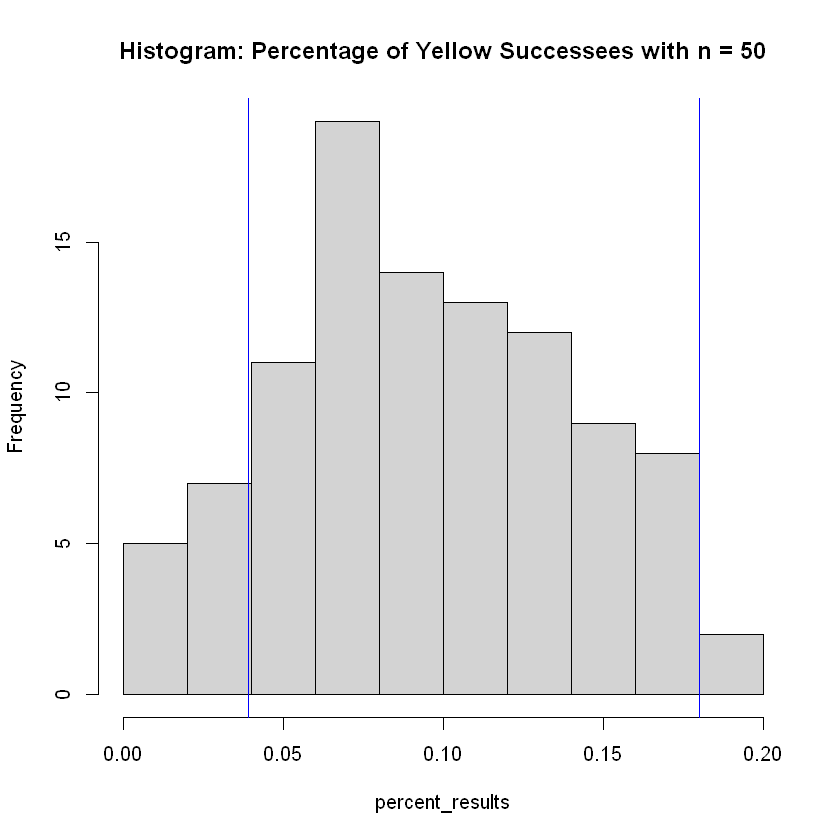

In [17]:
samp_size <- 50
number_trials <- 100
p <- c(0.2, 0.3, 0.4, 0.1)
lab <- c("Red", "Blue", "Green", "Yellow")

results <-do(number_trials) * rspin( n = samp_size, labels = lab , probs = p )
percent_results <- results[ , 'Yellow'] / samp_size
percent_results

lower <- quantile(percent_results, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(percent_results, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ', mean(percent_results),
    '\nand the 90% interval is from \n   ', lower, ' to ', upper )
hist(percent_results, breaks = 8, 
     main = paste('Histogram: Percentage of Yellow Successees with n =', samp_size ))
abline( v = lower, col="blue" )     # Add vertical line at 5th percentile
abline( v = upper, col="blue" )      # Add vertical line at 95th percentile

### Additional Tasks to Promote Understanding

1. Create code to run 1,000 trails with samples of size 100.
2. Increase sample size to 200, then to 500.
3. Notice the accuracy of our estimates and the width of the 90% intervals.

## Example 5: Dice Rolls

Use the appropriate sampling function to simulate the roll of a fair 6-sided die. Estimate the probability that face showing is a 5 or higher. Use your code to fill the following table. Note that within the **cat()** function, you will be able to insert either text or variables. This may adjust how you complete the coding of your sampling process.

In [23]:
cat('For the Roll of the Dice distribution, we find the following\n
   Sample Size     Estimate of Mean Percentage     90% Interval\n
     n = 50                                     \n
     n = 100                                    \n
     n = 200                                    \n
     n = 1,000')

For the Roll of the Dice distribution, we find the following

   Sample Size     Estimate of Mean Percentage     90% Interval

     n = 50                                     

     n = 100                                    

     n = 200                                    

     n = 1,000